# Component Tree Attribute as Image (a.k.a Attribute Maps)
Author : [Cyril Meyer](https://cyrilmeyer.eu/) (contact [at] cyrilmeyer [dot] eu) and Benjamin Perret.

In this notebook, you will learn how to compute attribute maps and optimized attribute maps as proposed in [1] using [Higra](https://github.com/higra/Higra).
The concept of attribute maps is to use attribute value as the output pixel value.
Those attribute maps can then be used for various image processing applications.

Each pixel `p` belongs to several nodes (the connected component `N` including `p` and all the nodes of its branch).
To associate a unique value to each pixel, different policies can be used, by keeping the maximum, the minimum or the mean value of the attributes of the branch nodes. The simplest policy actually being to use directly `N`.

Optimized attribute maps are attribute maps in which a specific criterion (a computed attribute) is used to select the node, this criterion being different from the attribute use for the output pixel value.

## References
* [1] Meyer, C., Baudrier, É., Schultz, P., Naegel, B. (2023). Combining Max-Tree and CNN for Segmentation of Cellular FIB-SEM Images. In: Kerautret, B., Colom, M., Krähenbühl, A., Lopresti, D., Monasse, P., Perret, B. (eds) Reproducible Research in Pattern Recognition. RRPR 2022. Lecture Notes in Computer Science, vol 14068. Springer, Cham. https://doi.org/10.1007/978-3-031-40773-4_7
* [2] D. L. Farfan Cabrera, N. Gogin, D. Morland, B. Naegel, D. Papathanassiou and N. Passat, "Segmentation of Axillary and Supraclavicular Tumoral Lymph Nodes in PET/CT: A Hybrid CNN/Component-Tree Approach," 2020 25th International Conference on Pattern Recognition (ICPR), Milan, Italy, 2021, pp. 6672-6679. https://doi.org/10.1109/ICPR48806.2021.9412343
* [Cyril-Meyer/DGMM2022-RRPR-CTAISegmentationCNN](https://github.com/Cyril-Meyer/DGMM2022-RRPR-CTAISegmentationCNN)
* [Cyril-Meyer/LibTIM](https://github.com/Cyril-Meyer/libtim)


## Requirements

In [1]:
%%capture
%pip install higra 
%pip install numpy 
%pip install matplotlib

In [2]:
import higra as hg
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# DO NOT USE np.inf
inf = 1e100

### Toy example

This is the image we will play with.

In [4]:
img_toy = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                    [0, 4, 3, 4, 0, 0, 0, 2, 2, 0],
                    [0, 2, 3, 3, 2, 1, 2, 2, 0, 0],
                    [0, 2, 4, 3, 2, 1, 0, 1, 0, 0],
                    [0, 0, 2, 0, 0, 0, 0, 0, 0, 0],
                    [0, 0, 0, 0, 3, 0, 4, 2, 0, 0],
                    [0, 1, 1, 0, 3, 2, 4, 4, 0, 0],
                    [0, 1, 1, 0, 3, 0, 4, 4, 1, 0],
                    [0, 1, 1, 0, 0, 0, 0, 1, 1, 0],
                    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]], dtype=np.uint8)

100 (10, 10) [0 1 2 3 4]


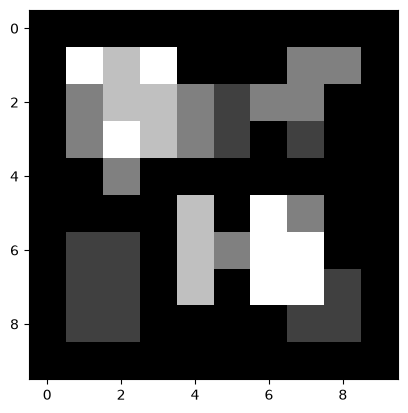

In [5]:
image = img_toy

print(image.size, image.shape, np.unique(image))
plt.imshow(image, cmap='gray')
plt.show()

We compute the Max-Tree of the image

In [6]:
g = hg.get_4_adjacency_implicit_graph(image.shape)
tree, altitudes = hg.component_tree_max_tree(g, vertex_weights=image)

### Area Map

Lets compute the attribute map of our image.
In this example, the attribute used is the area.

In [7]:
# compute area attribute
area = hg.attribute_area(tree)
# construct attribute map for attribute area
area_map = hg.reconstruct_leaf_data(tree, area)

Plot area map with value for each pixel (exact value in red).

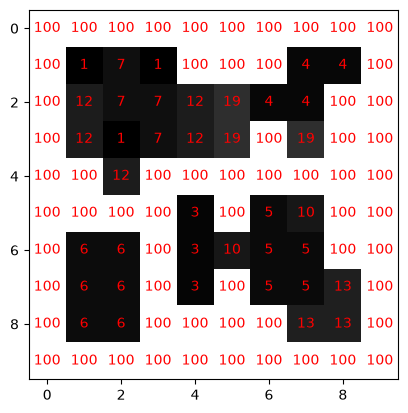

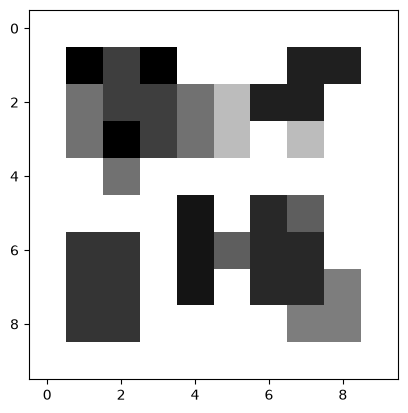

In [8]:
plt.imshow(area_map, cmap='gray')
for (j,i),label in np.ndenumerate(area_map):
  plt.text(i, j, int(label), ha='center', va='center', color='red')
plt.show()

plt.imshow(np.clip(area_map * 10, 0, 255), cmap='gray') # map * 10 to improve brightness
plt.show()

### Criterion $\nabla_A(N)$ and $\Delta_A(N)$ and Optimized Attribute Maps [1]

We compute two attribute, named $\nabla_A$ and $\Delta_A$.

$\nabla_A(N) = \frac{\mid A(Par(N)) - A(N)\mid}{|H(Par(N))-H(N)|} \cdot \frac{1}{A(N)}$

$\Delta_A(N) = \nabla_A(Par(N)) - \nabla_A(N)$

In [9]:
nabla = np.full(altitudes.shape, -inf, dtype=np.float64)
delta = np.full(altitudes.shape, -inf, dtype=np.float64)

for n in tree.root_to_leaves_iterator(include_leaves=False, include_root=False):
    nabla[n] = (area[tree.parent(n)] - area[n]) / (altitudes[n] - altitudes[tree.parent(n)]) / (area[n])

for n in tree.root_to_leaves_iterator(include_leaves=False, include_root=False):
    delta[n] = nabla[tree.parent(n)] - nabla[n]

We can use those attribute as any other and reconstruct an attribute map.

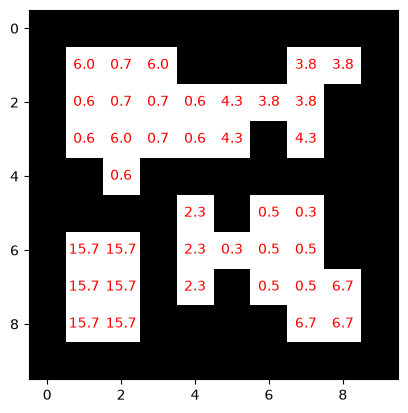

In [10]:
nabla_map = hg.reconstruct_leaf_data(tree, nabla)

plt.imshow(nabla_map, cmap='gray')
for (j,i),label in np.ndenumerate(nabla_map):
  label = '' if label == -inf else round(label,1)
  plt.text(i, j, label, ha='center', va='center', color='red')
plt.show()

Or we can use an attribute as a criterion to select nodes.

In [11]:
def index_of_max_ancestor_vec(tree, attr):
  """
  for any node n, anc(n) denotes the set of ancestors of n (n is an ancestor of itself)
  res[n] = argmax_{p in anc(n)} attr(p)
  """
  # compute max attr value among ancestors
  max_anc = hg.propagate_sequential_and_accumulate(tree, attr, hg.Accumulators.max)
  # propagate the index of those nodes who where the max values
  ind_max_anc = hg.propagate_sequential(tree, np.arange(tree.num_vertices()), attr != max_anc)

  return ind_max_anc

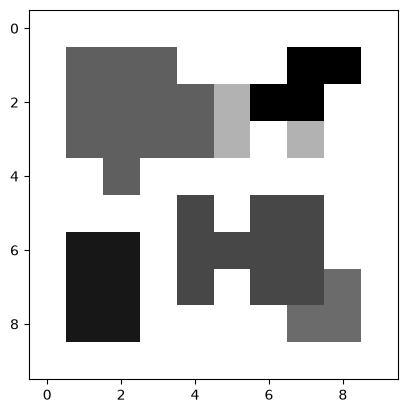

In [12]:
# attribute for the pixel value
attribute = area
# attribute used as criterion to select node for the pixel
criterion = delta
# for each pixel, we get the node with maximized criterion
ind_max_anc = index_of_max_ancestor_vec(tree, criterion)
# we reconstruct an attribute map with optimized node selection
area_map_optimized = hg.reconstruct_leaf_data(tree, attribute[ind_max_anc])
# and show the result
plt.imshow(np.clip(area_map_optimized * 10, 0, 255), cmap='gray') # map * 10 to improve brightness
plt.show()